In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import warnings
warnings.filterwarnings("ignore")


In [5]:
df=pd.read_csv('clothes_price_prediction_data.csv')

In [7]:
df.head()

,Brand,Category,Color,Size,Material,Price
0,New Balance,Dress,White,XS,Nylon,182
1,New Balance,Jeans,Black,XS,Silk,57
2,Under Armour,Dress,Red,M,Wool,127
3,Nike,Shoes,Green,M,Cotton,77
4,Adidas,Sweater,White,M,Nylon,113


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Brand     1000 non-null   object
 1   Category  1000 non-null   object
 2   Color     1000 non-null   object
 3   Size      1000 non-null   object
 4   Material  1000 non-null   object
 5   Price     1000 non-null   int64 
dtypes: int64(1), object(5)
memory usage: 47.0+ KB


In [9]:
df.isnull().sum()

Brand       0
Category    0
Color       0
Size        0
Material    0
Price       0
dtype: int64

In [10]:
df.columns

Index(['Brand', 'Category', 'Color', 'Size', 'Material', 'Price'], dtype='object')

<Axes: xlabel='Brand', ylabel='count'>

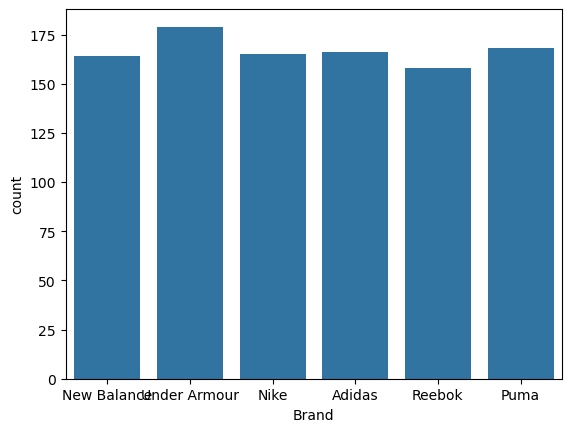

In [12]:
sns.countplot(data=df,x='Brand')

In [86]:
df = df.drop('Brand', axis=1)

In [87]:
sns.boxplot(data=df, x='Brand', y='Price')
plt.xticks(rotation=90)

ValueError: Could not interpret value `Brand` for `x`. An entry with this name does not appear in `data`.

In [ ]:
sns.boxplot(data=df, x='Category', y='Price')


<Axes: xlabel='Price', ylabel='Count'>

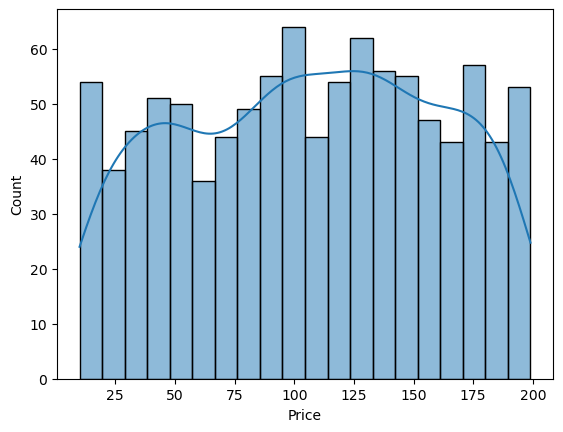

In [88]:
sns.histplot(df['Price'], bins=20,kde=True)

([0, 1, 2, 3, 4, 5],
 [Text(0, 0, 'Nylon'),
  Text(1, 0, 'Silk'),
  Text(2, 0, 'Wool'),
  Text(3, 0, 'Cotton'),
  Text(4, 0, 'Polyester'),
  Text(5, 0, 'Denim')])

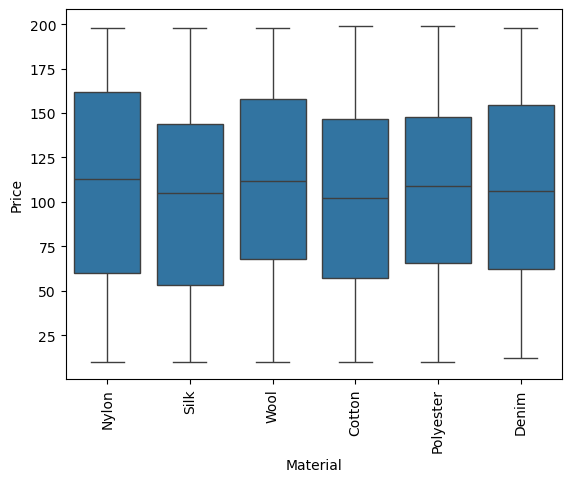

In [89]:
sns.boxplot(data=df, x='Material', y='Price')
plt.xticks(rotation=90)

([0, 1, 2, 3, 4, 5],
 [Text(0, 0, 'XS'),
  Text(1, 0, 'M'),
  Text(2, 0, 'XL'),
  Text(3, 0, 'XXL'),
  Text(4, 0, 'S'),
  Text(5, 0, 'L')])

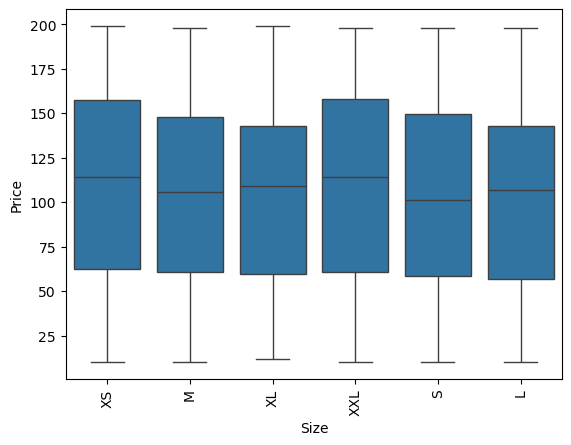

In [90]:
sns.boxplot(data=df, x='Size', y='Price')
plt.xticks(rotation=90)

In [91]:
sns.boxplot(data=df, x= 'Color', y='Price')
plt.xticks(rotation=90)

ValueError: Could not interpret value `Color` for `x`. An entry with this name does not appear in `data`.

In [92]:
df = df.drop('Color', axis=1)

KeyError: "['Color'] not found in axis"

In [93]:
x=df.drop(columns=['Price'],axis=1)

In [94]:
x

,Category,Size,Material
0,Dress,XS,Nylon
1,Jeans,XS,Silk
2,Dress,M,Wool
3,Shoes,M,Cotton
4,Sweater,M,Nylon
...,...,...,...
995,Jeans,L,Polyester
996,Jacket,XXL,Silk
997,Sweater,XS,Denim
998,Sweater,XXL,Denim


In [95]:
y=df['Price']

In [96]:
y


0      182
1       57
2      127
3       77
4      113
      ... 
995    176
996    110
997    127
998     69
999    174
Name: Price, Length: 1000, dtype: int64

In [97]:
x.columns

Index(['Category', 'Size', 'Material'], dtype='object')

In [106]:
endoer1=pd.get_dummies(x,columns=[ 'Category',  'Size', 'Material'],drop_first=True)

In [107]:
endoer1

,Category_Jacket,Category_Jeans,Category_Shoes,Category_Sweater,Category_T-shirt,Size_M,Size_S,Size_XL,Size_XS,Size_XXL,Material_Denim,Material_Nylon,Material_Polyester,Material_Silk,Material_Wool
0,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False
1,False,True,False,False,False,False,False,False,True,False,False,False,False,True,False
2,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True
3,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False
4,False,False,False,True,False,True,False,False,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False
996,True,False,False,False,False,False,False,False,False,True,False,False,False,True,False
997,False,False,False,True,False,False,False,False,True,False,True,False,False,False,False
998,False,False,False,True,False,False,False,False,False,True,True,False,False,False,False


In [108]:
endoer1=endoer1.astype(int)

In [109]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [110]:
X_train, X_test, y_train, y_test = train_test_split(endoer1, y, test_size=0.33, random_state=42)

In [111]:
model=LinearRegression()
model.fit(X_train , y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [112]:
y_pred=model.predict( X_test)

In [113]:
y_pred

array([110.17831223, 123.25583587, 103.54806224, 110.12949954,
       105.17922256,  99.07827813, 110.09589225, 108.78397226,
       102.80739889,  93.46554907, 104.65020123, 109.7145408 ,
       104.52234181,  97.49143897, 118.50920173, 110.17831223,
        99.97365483, 122.2815563 , 104.65020123, 107.09406764,
       109.7145408 , 103.54806224, 105.87029251, 114.283602  ,
       109.57856997, 104.31726603, 106.6320738 ,  95.97216641,
       100.1076524 ,  95.75966813,  99.26266519, 111.96137173,
       107.67597468, 109.62895947, 108.85389709, 104.02855511,
       111.0541857 , 106.96007007,  99.26266519, 103.97012071,
        97.15850377, 105.68590544,  93.64993614, 110.45869406,
       110.17831223, 115.84031233, 102.80739889, 111.98924991,
       118.50920173,  94.31481607,  97.20889327, 101.44818061,
       110.51124743, 105.75620033, 113.86824682, 112.9356513 ,
       115.84031233,  93.64993614, 117.78079471, 102.06324563,
       106.35714497,  99.44277247, 114.283602  , 119.05

In [114]:
 y_test

521    101
737    164
740     58
660     82
411    177
      ... 
506    171
342    170
485    139
711    128
133    165
Name: Price, Length: 330, dtype: int64

In [115]:
r2=r2_score( y_test,y_pred)
r2

-0.009520216070349807

In [116]:
n=X_test.shape[0]
p=X_test.shape[1]
adjested_r2=1-(1-r2)*(n-1)/(n-p-1)

In [117]:
adjested_r2

-0.05774570409918822

In [ ]:
S